# **Live Coding BAB 6 Algoritma Klasifikasi Support Vector Machine**

- Nama    : Sayyidah Fatimah Azzahra
- NIM     : 235150200111064
- Kelas   : TIF-E

## **1. Import Library**

**Import library standar yang diperlukan, seperti pandas, numpy, dan sebagainya**

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Load Dataset**

**a. Import dataset dari link yang sudah diberikan, dibebaskan menggunakan metode apapun untuk loading dataset.**

In [57]:
df = pd.read_csv("dataset/penguins.csv")

**b. *Cetak* dataset**

In [58]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [59]:
df['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

**c. *Deskripsi* dataset**

In [60]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550

## **3. Preprocessing**

**a. Ambil indeks fitur numerik dan kategorikal**

In [61]:
numerical_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(exclude=['number']).columns

print("Fitur Numerik: ", numerical_features)
print("Fitur Kategorikal: ", categorical_features)

Fitur Numerik:  Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')
Fitur Kategorikal:  Index(['species', 'island', 'sex'], dtype='object')


**b. Transformasi nilai 0 ke NaN untuk data numerik**

In [62]:
df = df.replace(0, np.nan)

**c. Missing Value**

In [63]:
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


Lakukan imputasi data, dengan ketentuan untuk fitur numerik, data NaN diubah menggunakan fungsi **mean** serta untuk fitur kategorikal, data NaN diubah menggunakan fungsi **modus/mode**

In [64]:
def imputasi(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode())
        else:
            df[col] = df[col].fillna(df[col].mean())
    return df

In [65]:
df_imp = imputasi(df)

In [66]:
df_imp['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

**d. Cek Outlier**

Cek apakah terdapat outlier. Jika ada, lakukan outlier handling

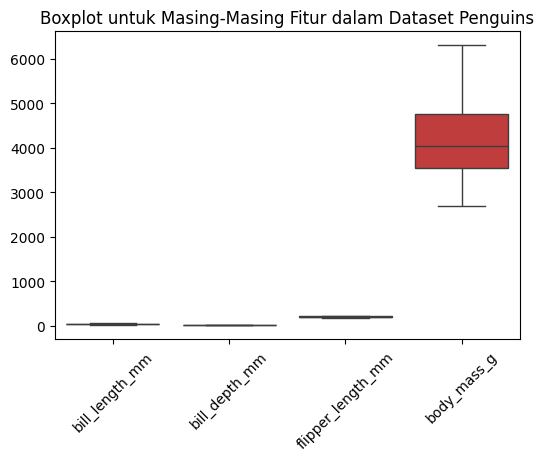

In [67]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_imp[numerical_features])
plt.xticks(rotation=45)
plt.title("Boxplot untuk Masing-Masing Fitur dalam Dataset Penguins")
plt.show()

**e. Normalisasi Data**

In [68]:
def minmax(df_input, fitur):
    for fitur in fitur:
        max_val = df_input[fitur].max()
        min_val = df_input[fitur].min()
        if max_val != min_val:
            df_input[fitur] = (df_input[fitur] - min_val) / (max_val - min_val)
        else:
            df_input[fitur] = 0
    return df_input

In [69]:
def cetak_rentang(df_input, list_fitur):
    for fitur in list_fitur:
        max_val = df_input[fitur].max()
        min_val = df_input[fitur].min()
        print(f"Rentang fitur {fitur} adalah {max_val - min_val}")

In [70]:
cetak_rentang(df_imp, numerical_features)

Rentang fitur bill_length_mm adalah 27.5
Rentang fitur bill_depth_mm adalah 8.4
Rentang fitur flipper_length_mm adalah 59.0
Rentang fitur body_mass_g adalah 3600.0


**Apply normalisasi**

In [71]:
df_norm = minmax(df_imp, numerical_features)

In [72]:
cetak_rentang(df_norm, numerical_features)

Rentang fitur bill_length_mm adalah 1.0
Rentang fitur bill_depth_mm adalah 1.0
Rentang fitur flipper_length_mm adalah 1.0
Rentang fitur body_mass_g adalah 1.0


In [73]:
df_norm['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

**b. Lakukan label encoding untuk fitur/kolom kategorikal!**

In [74]:
def label_encoding(df, categorical_features):
    for feature in categorical_features:
        unique_values = df[feature].copy().unique()
        mapping = {val: idx for idx, val in enumerate(unique_values)}

        df[feature] = df[feature].map(mapping)

    return df  # Return the encoded dataframe

In [75]:
df_encoded = label_encoding(df_norm, categorical_features)

In [76]:
df_encoded['species'].unique()

array([0, 1, 2])

## **4. Biner**

**a. Copy dataframe terbaru untuk klasifikasi biner**

In [77]:
df_biner = df_encoded.copy()

**b. drop kelas** *Chinstrap*

In [78]:
df_biner['species'].unique()

array([0, 1, 2])

In [79]:
df_biner = df_biner.drop(df[df['species']=='Chinstrap'].index)

In [80]:
df_biner['species'].unique()

array([0, 1, 2])

In [81]:
df_biner.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,2,2,0.861818,0.797619,0.593220,0.361111,0
340,2,2,0.414545,0.595238,0.508475,0.194444,1
341,2,2,0.636364,0.607143,0.355932,0.298611,0
342,2,2,0.680000,0.702381,0.644068,0.388889,0
343,2,2,0.658182,0.666667,0.440678,0.298611,1


**c. Lakukan encoding pada kolom kelas dengan mengubahnya menjadi -1 dan 1**

In [82]:
df_biner['species'] = df_biner['species'].map({0: -1, 1: 1})

In [83]:
df_biner['species'].unique()

array([-1.,  1., nan])

In [84]:
df_biner.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            276 non-null    float64
 1   island             344 non-null    int64  
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 18.9 KB


In [85]:
# kalau tidak didrop, akurasinya jadi 1 dan kemungkinan model jadi tidak bisa generalisasi dengan baik :)

# df_biner = df_biner.dropna(subset=['species'])
# df_biner['species'].unique()

In [86]:
df_biner.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            276 non-null    float64
 1   island             344 non-null    int64  
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 18.9 KB


**d. Split data menjadi data latih dan data uji**

In [87]:
from sklearn.model_selection import train_test_split

data_latih, data_uji = train_test_split(df_biner, test_size=0.2, random_state=42)

**e. Buat label latih dan label uji dengan mengeluarkan kolom label pada data latih dan data uji**

In [88]:
label_latih = data_latih.pop('species')
label_uji = data_uji.pop('species')

**f. buat fungsi untuk menghitung gradient**

In [89]:
def hitung_cost_gradient(W, X, Y, regularization):
    jarak = 1 - (Y*np.dot(X,W))
    dw = np.zeros(len(W))
    if max(0,jarak)==0:
        di=W
    else:
        di = W - (regularization * Y*X)
    dw += di
    return dw

**g. buat fungsi untuk SGD untuk meminimalkan cost function**

In [90]:
from sklearn.utils import shuffle

def sgd(data_latih, label_latih, learning_rate=0.000001, max_epoch=1000, regularization=10000):
    data_latih = data_latih.to_numpy()
    label_latih = label_latih.to_numpy()
    bobot = np.zeros(data_latih.shape[1])
    for epoch in range(1, max_epoch):
        X,Y =shuffle(data_latih, label_latih, random_state=101)
        for index, x in enumerate(X):
            delta=hitung_cost_gradient(bobot,x,Y[index], regularization)
            bobot = bobot - (learning_rate * delta)
    return bobot

In [91]:
W = sgd(data_latih, label_latih)
print(W)

[ 0.0673328   2.35913652 -6.97053989  1.79778948  2.40014627  0.1043177 ]


**h. buat fungsi untuk melakukan testing**

In [92]:
def testing(W,data_uji):
  prediksi = np.array([])
  for i in range(data_uji.shape[0]):
    y_prediksi = np.sign(np.dot(W,data_uji.to_numpy()[i]))
    prediksi = np.append(prediksi,y_prediksi)
  return prediksi

In [93]:
y_prediksi = testing(W, data_uji)
print(sum(y_prediksi==label_uji)/len(label_uji))

0.8115942028985508


## **5. Multi-Class**

**a. copy dataframe yang telah di preprocess**

In [94]:
df_multi = df_encoded.copy()

**b. bagi dataset menjadi data latih dan data uji dengan perbandingan dibebaskan**

In [95]:
from sklearn.model_selection import train_test_split

data_latih, data_uji = train_test_split(df_multi, test_size=0.2, random_state=42)

**c. Buat label uji dengan mengeluarkan kolom kelas dari data uji**

In [96]:
label_uji = data_uji.pop('species')

### **One v Rest**

**Buat trainingset untuk model OVR**

In [97]:
def buat_trainingset(dataset):
    trainingset = {}
    kolom_kelas = dataset.columns[0]
    list_kelas = dataset[kolom_kelas].unique()
    for kelas in list_kelas:
        data_temp = dataset.copy(deep=True)
        data_temp[kolom_kelas] = data_temp[kolom_kelas].map({kelas: 1})
        data_temp[kolom_kelas] = data_temp[kolom_kelas].fillna(-1)
        trainingset[kelas] = data_temp
    return trainingset

In [98]:
trainingset = buat_trainingset(data_latih)

**buat fungsi training model OVR**

In [99]:
def training(trainingset):
    list_kelas = trainingset.keys()
    w = {}
    for kelas in list_kelas:
        data_latih = trainingset[kelas]
        label_latih = data_latih.pop('species')
        w[kelas] = sgd(data_latih, label_latih)
    return w

In [100]:
W = training(trainingset)

**Buat fungsi testing untuk model OVR**

In [101]:
def testing(W, data_uji):
    prediksi = []
    data_uji = data_uji.to_numpy()

    for i in range(data_uji.shape[0]):
        skor_kelas = {kelas: np.dot(W[kelas], data_uji[i]) for kelas in W.keys()}
        kelas_prediksi = max(skor_kelas, key=skor_kelas.get)
        prediksi.append(kelas_prediksi)

    return prediksi

In [102]:
y_prediksi = testing(W, data_uji)

In [103]:
print(sum(y_prediksi==label_uji)/len(label_uji))

0.9855072463768116


### **One v One**

**Buat trainingset untuk model OVO**

In [104]:
from itertools import combinations

def buat_trainingset_ovo(dataset):
    trainingset = {}
    kolom_kelas = dataset.columns[0]
    list_kelas = dataset[kolom_kelas].unique()

    # Buat kombinasi pasangan kelas untuk OvO
    for kelas1, kelas2 in combinations(list_kelas, 2):
        # Ambil hanya data dari dua kelas ini
        data_temp = dataset[(dataset[kolom_kelas] == kelas1) | (dataset[kolom_kelas] == kelas2)].copy()

        # Labeling: kelas1 = 1, kelas2 = -1
        data_temp[kolom_kelas] = data_temp[kolom_kelas].map({kelas1: 1, kelas2: -1})

        # Simpan dalam dictionary dengan key (kelas1, kelas2)
        trainingset[(kelas1, kelas2)] = data_temp

    return trainingset


In [105]:
trainingset_ovo = buat_trainingset_ovo(data_latih)

**Buat fungsi untuk training model OVO**

In [106]:
def training_ovo(trainingset):
    w = {}
    for (label1, label2), data in trainingset.items():
        label_latih = data.pop(data.columns[-1])
        w[(label1, label2)] = sgd(data, label_latih)
    return w

In [107]:
W_ovo = training_ovo(trainingset_ovo)

**Buat fungsi testing untuk model OVO**

In [108]:
from collections import Counter

def testing(W, data_uji):
    prediksi = []
    data_uji = data_uji.copy()

    for i in range(data_uji.shape[0]):
        vote = []

        for (kelas1, kelas2), w in W.items():
            skor = np.dot(w, data_uji.iloc[i, :].to_numpy())

            if skor > 0:
                vote.append(kelas1)
            else:
                vote.append(kelas2)

        kelas_prediksi = Counter(vote).most_common(1)[0][0]
        prediksi.append(kelas_prediksi)

    return prediksi

In [109]:
y_prediksi = testing(W_ovo, data_uji)

In [110]:
print(sum(y_prediksi==label_uji)/len(label_uji))

0.463768115942029


**Pertanyaan**
1. Apa kelebihan dan kekurangan menggunakan metode OVO dibandingkan OVR?
2. Dalam situasi apa OVR lebih disarankan dibandingkan OVO, dan apa alasannya?
3. Bagaimana cara kerja hyperplane dalam SVM untuk memisahkan dua kelas dalam klasifikasi biner?

**JAWAB:**

1. OVO memiliki beberapa keunggulan, seperti akurasi yang lebih baik untuk dataset tidak seimbang dan pelatihan yang lebih cepat pada dataset besar. Namun, metode ini memerlukan lebih banyak model klasifikasi dan dapat memakan waktu lebih lama saat melakukan prediksi. Selain itu, hasil prediksi bisa menjadi tidak pasti jika terjadi kesetaraan dalam proses voting.

2. OVR lebih cocok digunakan pada dataset dengan jumlah kelas yang sangat banyak atau ketika kecepatan prediksi diprioritaskan. Metode ini juga efektif untuk dataset dengan jumlah kelas yang seimbang.

3. Cara kerja hyperplane SVM dalam klasifikasi biner meliputi beberapa langkah:
   - Menemukan hyperplane optimal yang dapat memisahkan dua kelas dengan baik
   - Memperbesar jarak (margin) antara hyperplane dan titik data terdekat dari kedua kelas
   - Memanfaatkan support vector (titik data terdekat) untuk menentukan posisi hyperplane
   - Mengaplikasikan fungsi kernel untuk menangani data yang tidak dapat dipisahkan secara linear
   - Mengklasifikasikan data baru berdasarkan posisinya terhadap hyperplane yang telah ditentukan
